# **Normal Distribution**



Kuch ml algos normal data pe achha perform krte h isliye ham normal distribution krte h

Sklearn me teen alag tranformation hote h :-

1. Function Transformer
2. Power Transformer
3. Quantile Transformer

# **Log Transformation**

-ve value pe nhi lagega

additive scale ko multiplicative scale pe le aata h


Other Transformations are

1. Reciprocal :- used for right sweked data
2. square of x :- usualy used for left skewed data
3. sqrt

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import  accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [ ]:
df=pd.read_csv('/content/train (1).csv',usecols=['Age','Fare','Survived'])

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [ ]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipython-input-694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [ ]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

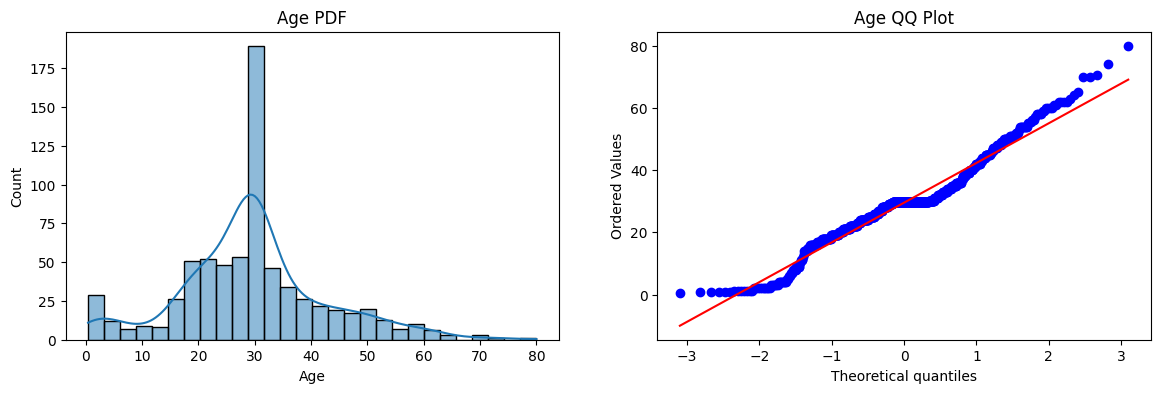

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(x_train['Age'],kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Age'],dist="norm",plot=plt)
plt.title('Age QQ Plot')

plt.show()

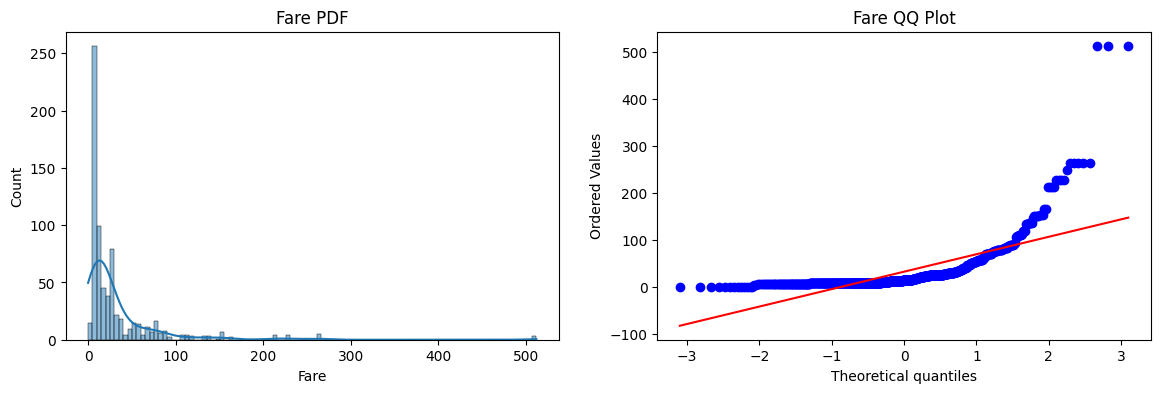

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(x_train['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(x_train['Fare'],dist="norm",plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [ ]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [ ]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred=clf.predict(x_test)
y_pred1=clf2.predict(x_test)

print("Accuracy Score LR: ",accuracy_score(y_pred,y_test))
print("Accuracy Score DT: ",accuracy_score(y_pred1,y_test))

Accuracy Score LR:  0.6480446927374302
Accuracy Score DT:  0.6927374301675978


In [ ]:
trf=FunctionTransformer(func=np.log1p)

In [ ]:
X_train_transformed=trf.fit_transform(x_train)
X_test_transformed=trf.transform(x_test)

In [ ]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [ ]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred=clf.predict(x_test)
y_pred1=clf2.predict(x_test)

print("Accuracy Score LR: ",accuracy_score(y_pred,y_test))
print("Accuracy Score DT: ",accuracy_score(y_pred1,y_test))

Accuracy Score LR:  0.6480446927374302
Accuracy Score DT:  0.6703910614525139


In [ ]:
x_transformed=trf.fit_transform(x)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
print("LR",np.mean(cross_val_score(clf,x_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,x_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6622097378277154


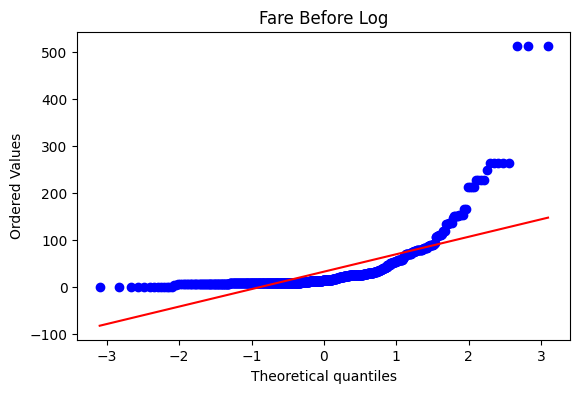

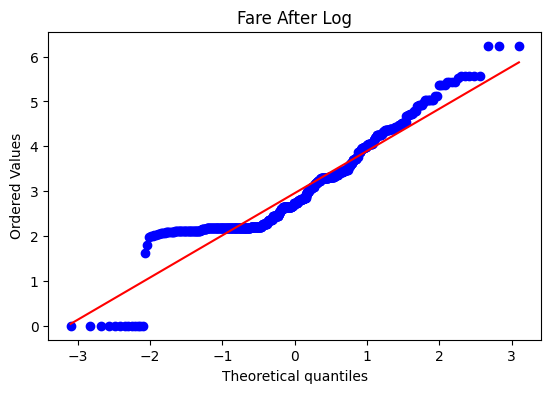

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train['Fare'],dist="norm",plot=plt)
plt.title('Fare Before Log')
plt.figure(figsize=(14,4))
plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist="norm",plot=plt)
plt.title('Fare After Log')

plt.show()

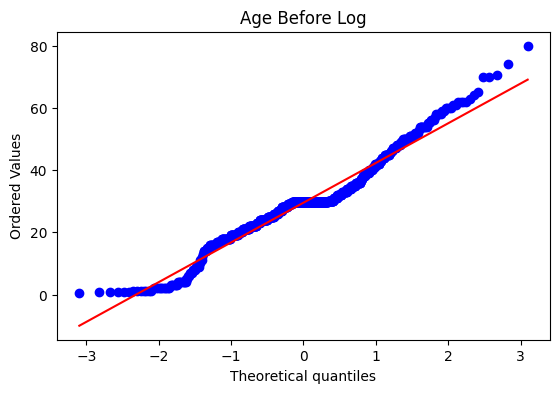

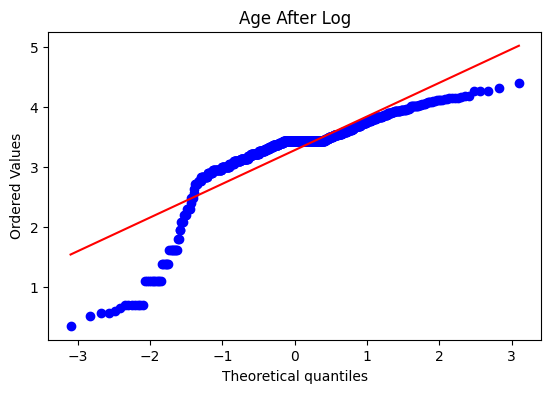

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train['Age'],dist="norm",plot=plt)
plt.title('Age Before Log')
plt.figure(figsize=(14,4))
plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist="norm",plot=plt)
plt.title('Age After Log')

plt.show()

In [ ]:
trf2=ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')
x_train_transformed2=trf2.fit_transform(x_train)
x_test_transformed2=trf2.transform(x_test)

In [ ]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred=clf.predict(x_test)
y_pred1=clf2.predict(x_test)

print("Accuracy Score LR: ",accuracy_score(y_pred,y_test))
print("Accuracy Score DT: ",accuracy_score(y_pred1,y_test))

Accuracy Score LR:  0.6480446927374302
Accuracy Score DT:  0.659217877094972
